In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\d2405\Downloads\factbook.csv")
df.head()

,Country,Area,Birth rate,Current account balance,Death rate,Electricity consumption,Electricity production,Exports,GDP,GDP per capita,...,Life expectancy at birth,Military expenditures,Natural gas consumption,Oil consumption,Population,Public debt,Railways,Reserves of foreign exchange & gold,Total fertility rate,Unemployment rate
0,Japan,"377,835",9.47,"$170,200,000,000.00",8.95,"971,000,000,000","1,044,000,000,000.00","$538,800,000,000.00","$3,745,000,000,000.00","$29,400.00",...,81.15,1,"80,420,000,000.00","5,290,000","127,417,244",164.3,23705,"664,600,000,000.00",1.39,4.7
1,Germany,"357,021",8.33,"$73,590,000,000.00",10.55,"519,500,000,000","560,000,000,000.00","$893,300,000,000.00","$2,362,000,000,000.00","$28,700.00",...,78.65,1.5,"99,550,000,000.00","2,891,000","82,431,390",65.8,46039,"96,840,000,000.00",1.39,10.6
2,Saudi Arabia,"1,960,582",29.56,"$51,500,000,000.00",2.62,"128,500,000,000","138,200,000,000.00","$113,000,000,000.00","$310,200,000,000.00","$12,000.00",...,75.46,10,"56,400,000,000.00","1,550,000","26,417,599",75,1392,"23,620,000,000.00",4.05,25
3,Russia,"17,075,200",9.80,"$46,040,000,000.00",14.52,"894,300,000,000","915,000,000,000.00","$162,500,000,000.00","$1,408,000,000,000.00","$9,800.00",...,67.10,,"405,800,000,000.00","2,310,000","143,420,309",28.2,87157,"124,500,000,000.00",1.27,8.3
4,Switzerland,"41,290",9.77,"$40,950,000,000.00",8.48,"54,530,000,000","63,470,000,000.00","$130,700,000,000.00","$251,900,000,000.00","$33,800.00",...,80.39,1,"3,093,000,000.00","290,400","7,489,370",57.2,4533,"69,580,000,000.00",1.42,3.4


In [3]:
df = df.replace(' ', np.nan)

In [4]:
df.rename(columns={'Country':'country', ' Area':'area', ' Birth rate':'birth rate', '  Current account balance ':'current account balance',
       ' Death rate':'death rate', ' Electricity consumption':'electricity consumption', '  Electricity production ':'electricity production',
       '  Exports ':'exports', '  GDP ':'gdp', '  GDP per capita ':'gdp per capita', ' GDP real growth rate':'gdp real growth rate',
       '  Highways ':'highways', '  Imports ':'imports', ' Industrial production growth rate':'industrial production growth rate',
       ' Infant mortality rate':'infant mortality rate', ' Inflation rate ':'inflation rate', '  Internet users ':'internet users',
       ' Investment':'investment', '  Labor force ':'labor force', ' Life expectancy at birth':'life expectancy at birth',
       ' Military expenditures':'military expenditures', '  Natural gas consumption ':'natural gas consumption',
       '  Oil consumption ':'oil consumption', '  Population ':'population', ' Public debt':'public debt', ' Railways':'railways',
       '  Reserves of foreign exchange & gold ':'reserves of foreign exchange and gold', ' Total fertility rate':'total fertility rate',
       ' Unemployment rate':'unemployement rate'}, inplace=True)

In [5]:
df = df[['exports', 'imports', 'industrial production growth rate', 'investment', 'unemployement rate', 'gdp']]
df.head()

,exports,imports,industrial production growth rate,investment,unemployement rate,gdp
0,"$538,800,000,000.00","$401,800,000,000.00",6.6,24,4.7,"$3,745,000,000,000.00"
1,"$893,300,000,000.00","$716,700,000,000.00",2.2,17.6,10.6,"$2,362,000,000,000.00"
2,"$113,000,000,000.00","$36,210,000,000.00",2.8,17.2,25,"$310,200,000,000.00"
3,"$162,500,000,000.00","$92,910,000,000.00",6.4,19.1,8.3,"$1,408,000,000,000.00"
4,"$130,700,000,000.00","$121,100,000,000.00",4.7,20.4,3.4,"$251,900,000,000.00"


In [6]:
df.shape

(149, 6)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 6 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   exports                            149 non-null    object
 1   imports                            149 non-null    object
 2   industrial production growth rate  134 non-null    object
 3   investment                         144 non-null    object
 4   unemployement rate                 127 non-null    object
 5   gdp                                149 non-null    object
dtypes: object(6)
memory usage: 7.1+ KB


In [8]:
pd.options.display.float_format = None

# Convert 'exports' column to string type
df['exports'] = df['exports'].astype(str)
# Remove unwanted characters and convert to float
df['exports'] = df['exports'].str.slice(stop=-2).str.replace(r'[\$, ]', '', regex=True).astype(float)

# Convert 'imports' column to string type
df['imports'] = df['imports'].astype(str)
# Remove unwanted characters and convert to float
df['imports'] = df['imports'].str.slice(stop=-2).str.replace(r'[\$, ]', '', regex=True).astype(float)

# Remove spaces and convert 'industrial production growth rate' column to float
df['industrial production growth rate'] = df['industrial production growth rate'].str.replace(' ', '').astype(float)

# Remove spaces and convert 'investment' column to float
df['investment'] = df['investment'].str.replace(' ', '').astype(float)

# Remove spaces and convert 'unemployment rate' column to float
df['unemployement rate'] = df['unemployement rate'].str.replace(' ', '').astype(float)

df['gdp'] = df['gdp'].str.slice(stop=-2).str.replace(r'[\$, ]', '', regex=True)
df['gdp'] = df['gdp'].astype(float)

In [9]:
df.head()

,exports,imports,industrial production growth rate,investment,unemployement rate,gdp
0,5.388000e+11,4.018000e+11,6.6,24.0,4.7,3.745000e+12
1,8.933000e+11,7.167000e+11,2.2,17.6,10.6,2.362000e+12
2,1.130000e+11,3.621000e+10,2.8,17.2,25.0,3.102000e+11
3,1.625000e+11,9.291000e+10,6.4,19.1,8.3,1.408000e+12
4,1.307000e+11,1.211000e+11,4.7,20.4,3.4,2.519000e+11


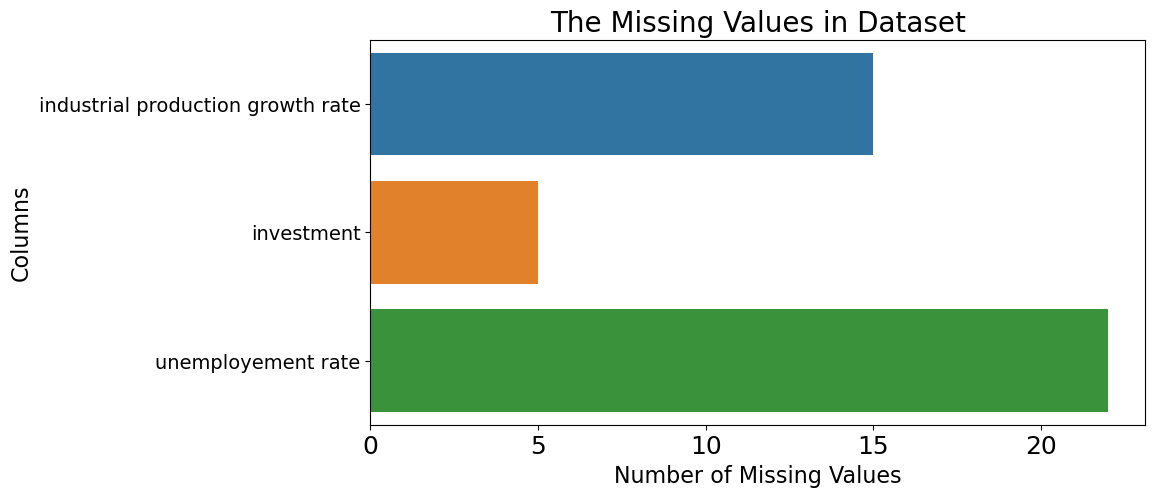

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count missing values
missing = df.isna().sum()

# Keep only columns with missing values
missing = missing[missing > 0]

# Plot missing values
plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing.values,
    y=missing.index,
    hue=missing.index,
    palette='tab10',
    legend=False
)

plt.xticks(fontsize=18)
plt.yticks(fontsize=14)

plt.xlabel("Number of Missing Values", fontsize=16)
plt.ylabel("Columns", fontsize=16)

plt.title('The Missing Values in Dataset', fontsize=20)

plt.show()

In [12]:
df_missing = df.isna().sum()
df_missing = df_missing.to_frame(name='missing')

df_missing = df_missing.reset_index()
df_missing = df_missing.rename(columns={'index':'attribute'})

df_missing 

,attribute,missing
0,exports,0
1,imports,0
2,industrial production growth rate,15
3,investment,5
4,unemployement rate,22
5,gdp,0


In [14]:
#fill missing value in more than one attribute
# Fill missing values with mean

df['industrial production growth rate'] = (
    df['industrial production growth rate']
    .fillna(df['industrial production growth rate'].mean())
)

df['investment'] = (
    df['investment']
    .fillna(df['investment'].mean())
)

df['unemployement rate'] = (
    df['unemployement rate']
    .fillna(df['unemployement rate'].mean())
)

In [15]:
# Hitung nilai minimum dan maksimum
min_val = df['exports'].min()
max_val = df['exports'].max()

# Normalisasi menggunakan Min-Max scaling
df['exports'] = (df['exports'] - min_val) / (max_val - min_val)

In [16]:
# Hitung nilai minimum dan maksimum
min_val = df['imports'].min()
max_val = df['imports'].max()

# Normalisasi menggunakan Min-Max scaling
df['imports'] = (df['imports'] - min_val) / (max_val - min_val)

In [17]:
# Hitung nilai minimum dan maksimum
min_val = df['industrial production growth rate'].min()
max_val = df['industrial production growth rate'].max()

# Normalisasi menggunakan Min-Max scaling
df['industrial production growth rate'] = (df['industrial production growth rate'] - min_val) / (max_val - min_val)

In [18]:
# Hitung nilai minimum dan maksimum
min_val = df['investment'].min()
max_val = df['investment'].max()

# Normalisasi menggunakan Min-Max scaling
df['investment'] = (df['investment'] - min_val) / (max_val - min_val)

In [19]:
# Hitung nilai minimum dan maksimum
min_val = df['gdp'].min()
max_val = df['gdp'].max()

# Normalisasi menggunakan Min-Max scaling
df['gdp'] = (df['gdp'] - min_val) / (max_val - min_val)

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
exports,149.0,0.065582,0.150255,0.0,0.001816,0.006915,0.043416,1.0
imports,149.0,0.039589,0.107316,0.0,0.001308,0.004930,0.026680,1.0
industrial production growth rate,149.0,0.371594,0.137521,0.0,0.288360,0.351852,0.412698,1.0
investment,149.0,0.240757,0.139799,0.0,0.162872,0.211909,0.281961,1.0
unemployement rate,149.0,14.470079,11.788412,0.6,6.600000,12.100000,15.000000,70.0
gdp,149.0,0.031543,0.104379,0.0,0.001315,0.004067,0.019318,1.0


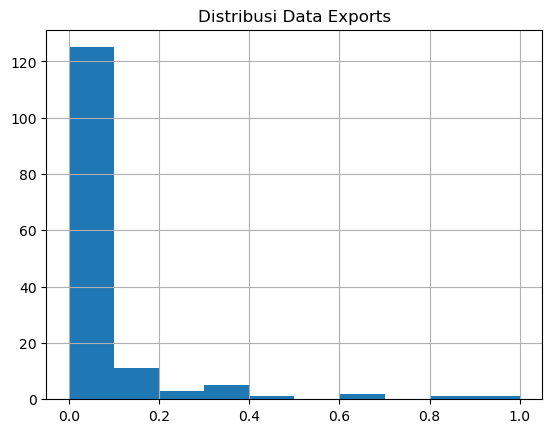

In [21]:
#Performing checks on the data distribution and outliers.
df['exports'].hist()
plt.title("Distribusi Data Exports")
plt.show()

Outliers:
0      0.603154
1      1.000000
6      0.652746
148    0.889958
Name: exports, dtype: float64



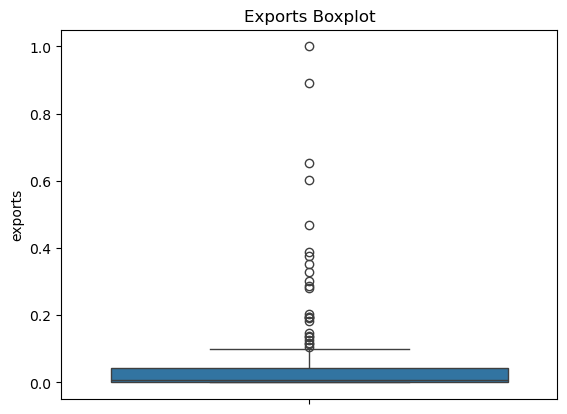

In [22]:
# Calculating the z-score for the 'exports' column
z_scores = (df['exports'] - df['exports'].mean()) / df['exports'].std()

# Identifying outliers with z-scores outside a certain range,
# for example z-score > 3 or z-score < -3
outliers_exports = df.loc[abs(z_scores) > 3, 'exports']

# Displaying the outliers
print("Outliers:")
print(outliers_exports)
print()

# Visualization using a box plot
sns.boxplot(data=df, y='exports')
plt.title("Exports Boxplot")
plt.show()

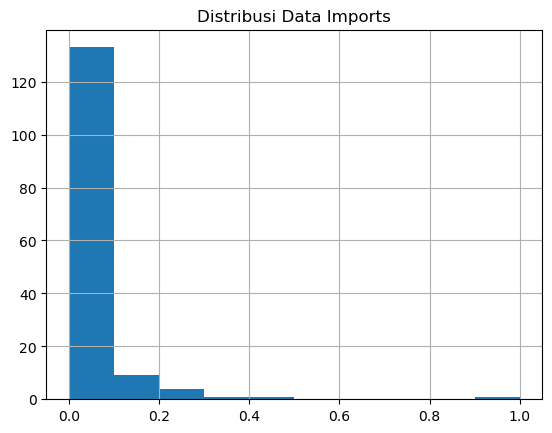

In [23]:
df['imports'].hist()
plt.title("Distribusi Data Imports")
plt.show()

Outliers:
1      0.485555
6      0.374237
148    1.000000
Name: imports, dtype: float64



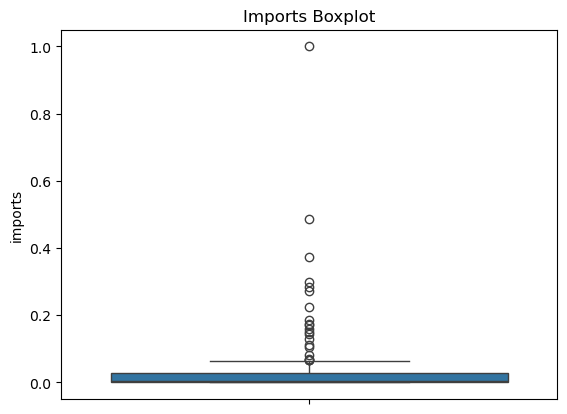

In [24]:
# Calculating the z-score for the 'imports' column
z_scores = (df['imports'] - df['imports'].mean()) / df['imports'].std()

# Identifying outliers with z-scores outside a certain range,
# for example z-score > 3 or z-score < -3
outliers_imports = df.loc[abs(z_scores) > 3, 'imports']

# Displaying the outliers
print("Outliers:")
print(outliers_imports)
print()

# Visualization using a box plot
sns.boxplot(data=df, y='imports')
plt.title("Imports Boxplot")
plt.show()

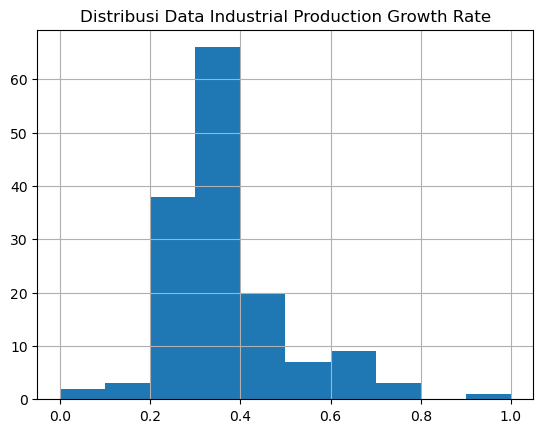

In [25]:
df['industrial production growth rate'].hist()
plt.title("Distribusi Data Industrial Production Growth Rate")
plt.show()

Outliers:
57     0.78836
58     0.78836
98     0.78836
109    1.00000
Name: industrial production growth rate, dtype: float64



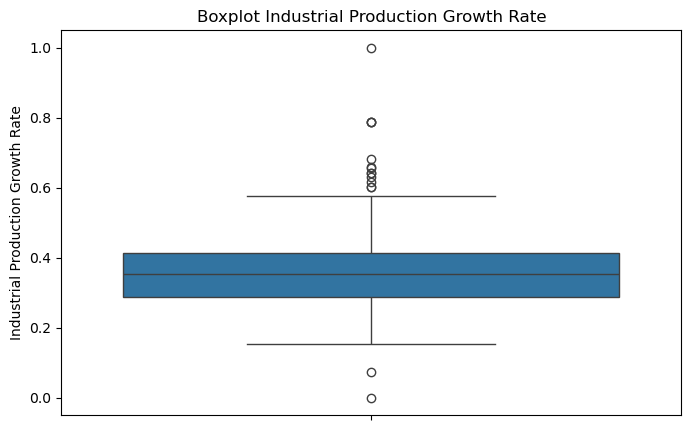

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculating the z-score for the 
# 'industrial production growth rate' column
z_scores = (
    df['industrial production growth rate']
    - df['industrial production growth rate'].mean()
) / df['industrial production growth rate'].std()

# Identifying outliers with z-scores outside 
# the range of -3 to 3
outliers_industrial = df.loc[
    abs(z_scores) > 3,
    'industrial production growth rate'
]

# Displaying the outliers
print("Outliers:")
print(outliers_industrial)
print()

# Visualization using a box plot
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    y='industrial production growth rate'
)

plt.title("Boxplot Industrial Production Growth Rate")
plt.ylabel("Industrial Production Growth Rate")

plt.show()

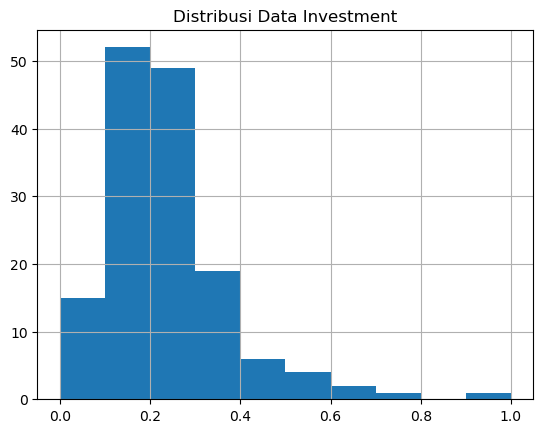

In [27]:
df['investment'].hist()
plt.title("Distribusi Data Investment")
plt.show()

Outliers:
6      0.665499
78     0.683012
109    0.749562
132    1.000000
Name: investment, dtype: float64



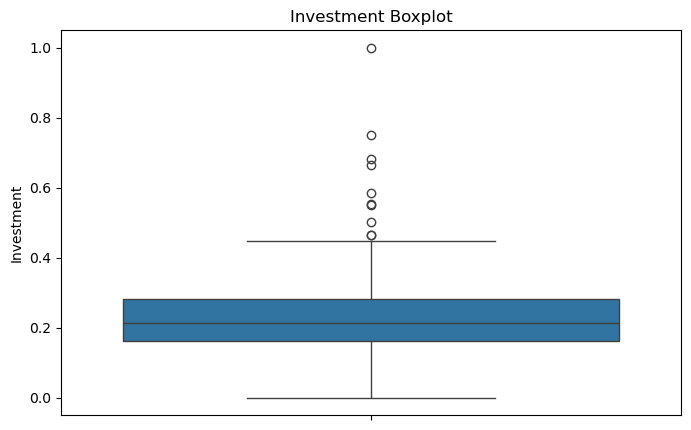

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculating the z-score for the 'investment' column
z_scores = (
    df['investment'] - df['investment'].mean()
) / df['investment'].std()

# Identifying outliers with z-scores outside
# the range of -3 to 3
outliers_investment = df.loc[
    abs(z_scores) > 3,
    'investment'
]

# Displaying the outliers
print("Outliers:")
print(outliers_investment)
print()

# Visualization using a box plot
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    y='investment'
)

plt.title("Investment Boxplot")
plt.ylabel("Investment")

plt.show()

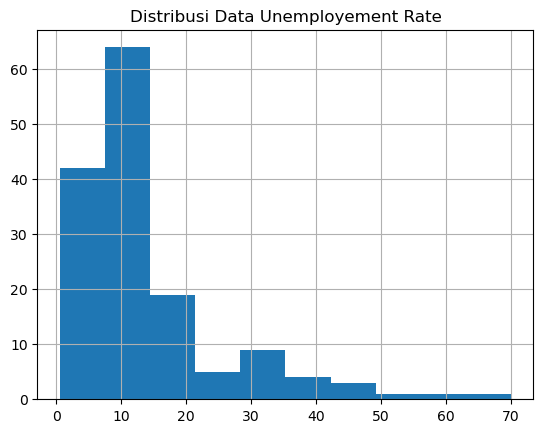

In [29]:
df['unemployement rate'].hist()
plt.title("Distribusi Data Unemployement Rate")
plt.show()

Outliers:
58    60.0
87    50.0
91    70.0
Name: unemployement rate, dtype: float64



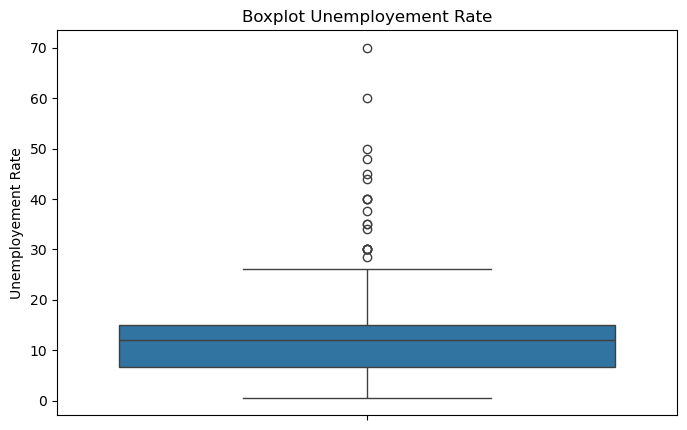

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculating the z-score for the 'unemployement rate' column
z_scores = (
    df['unemployement rate']
    - df['unemployement rate'].mean()
) / df['unemployement rate'].std()

# Identifying outliers with z-scores outside
# the range of -3 to 3
outliers_unemployement = df.loc[
    abs(z_scores) > 3,
    'unemployement rate'
]

# Displaying the outliers
print("Outliers:")
print(outliers_unemployement)
print()

# Visualization using a box plot
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    y='unemployement rate'
)

plt.title("Boxplot Unemployement Rate")
plt.ylabel("Unemployement Rate")

plt.show()

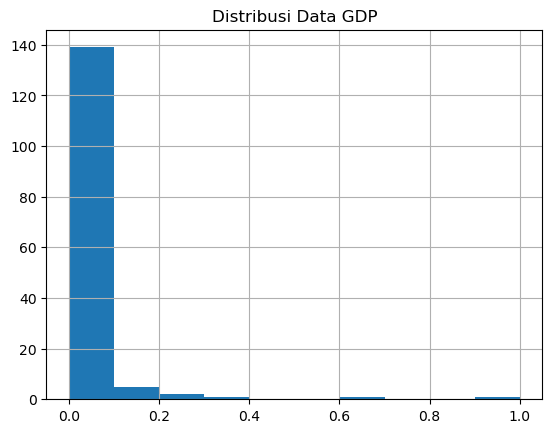

In [31]:
df['gdp'].hist()
plt.title("Distribusi Data GDP")
plt.show()

Outliers:
6      0.618036
148    1.000000
Name: gdp, dtype: float64



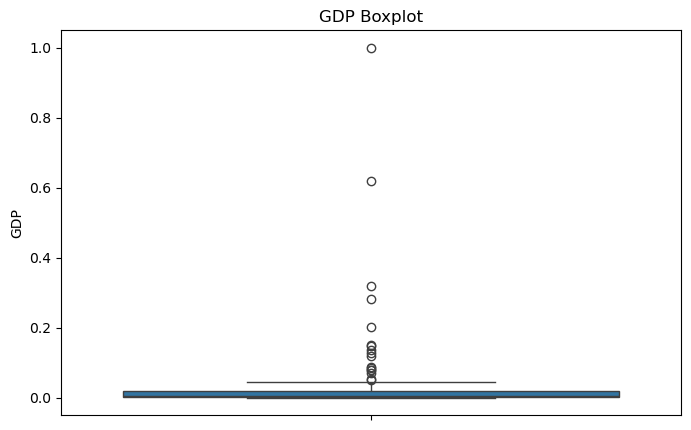

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculating the z-score for the 'gdp' column
z_scores = (
    df['gdp'] - df['gdp'].mean()
) / df['gdp'].std()

# Identifying outliers with z-scores outside
# the range of -3 to 3
outliers_gdp = df.loc[
    abs(z_scores) > 3,
    'gdp'
]

# Displaying the outliers
print("Outliers:")
print(outliers_gdp)
print()

# Visualization using a box plot
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    y='gdp'
)

plt.title("GDP Boxplot")
plt.ylabel("GDP")

plt.show()

C:\Users\d2405\AppData\Local\Temp\ipykernel_6668\59479991.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.hist(ax=ax)


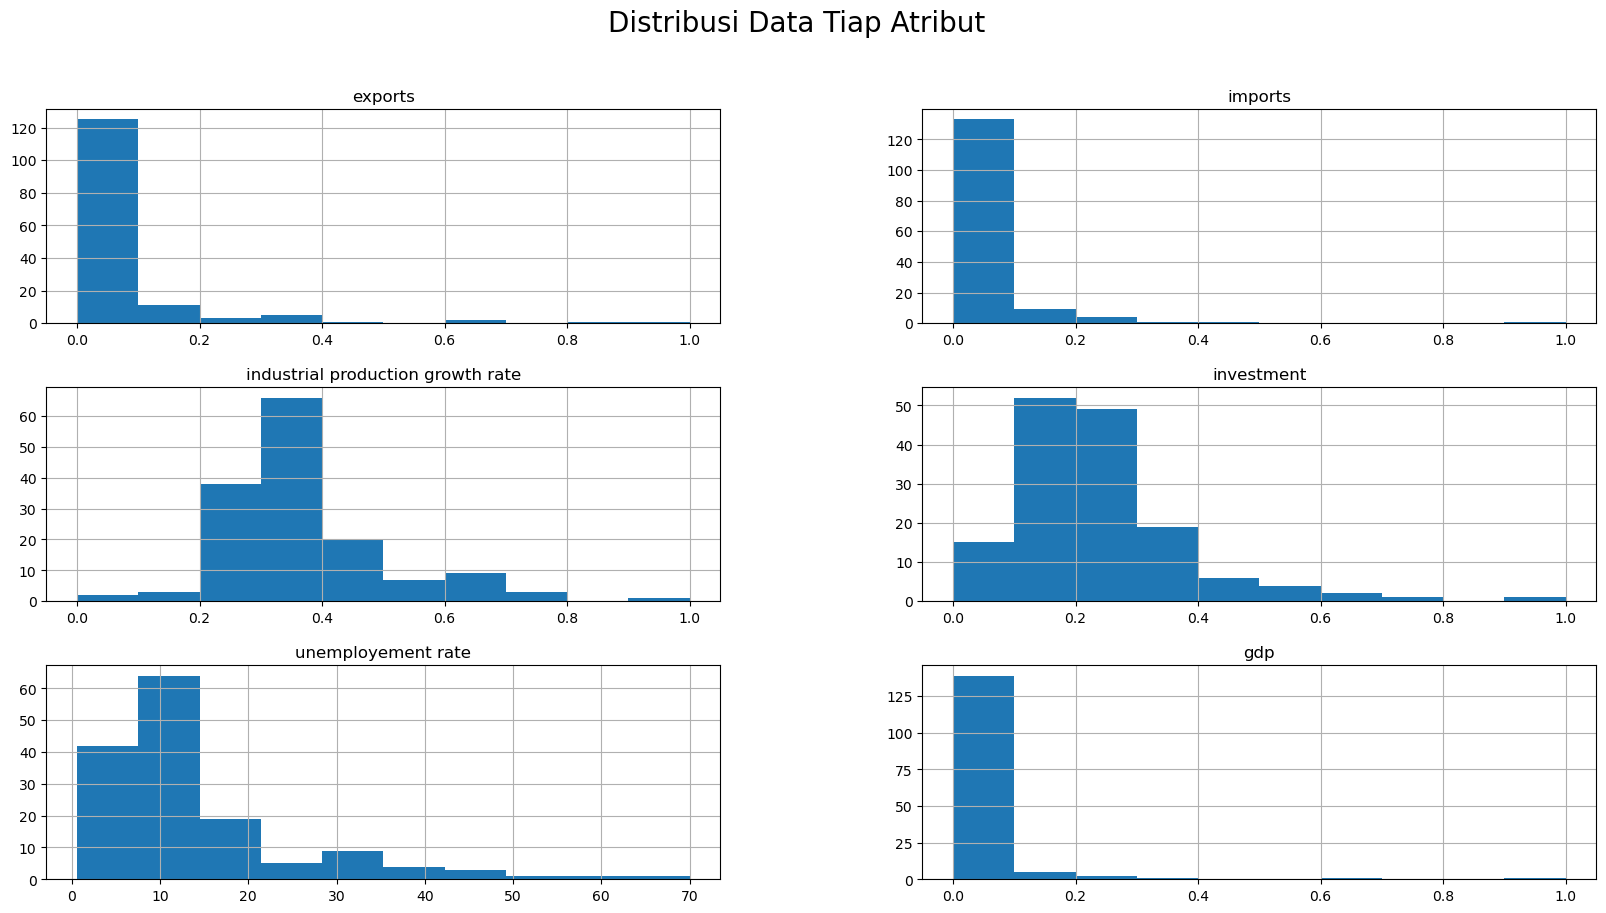

In [33]:
#Overall data distribution.
fig, ax = plt.subplots(figsize=(20, 10))
df.hist(ax=ax)
plt.suptitle("Distribusi Data Tiap Atribut", fontsize=20)
plt.show()

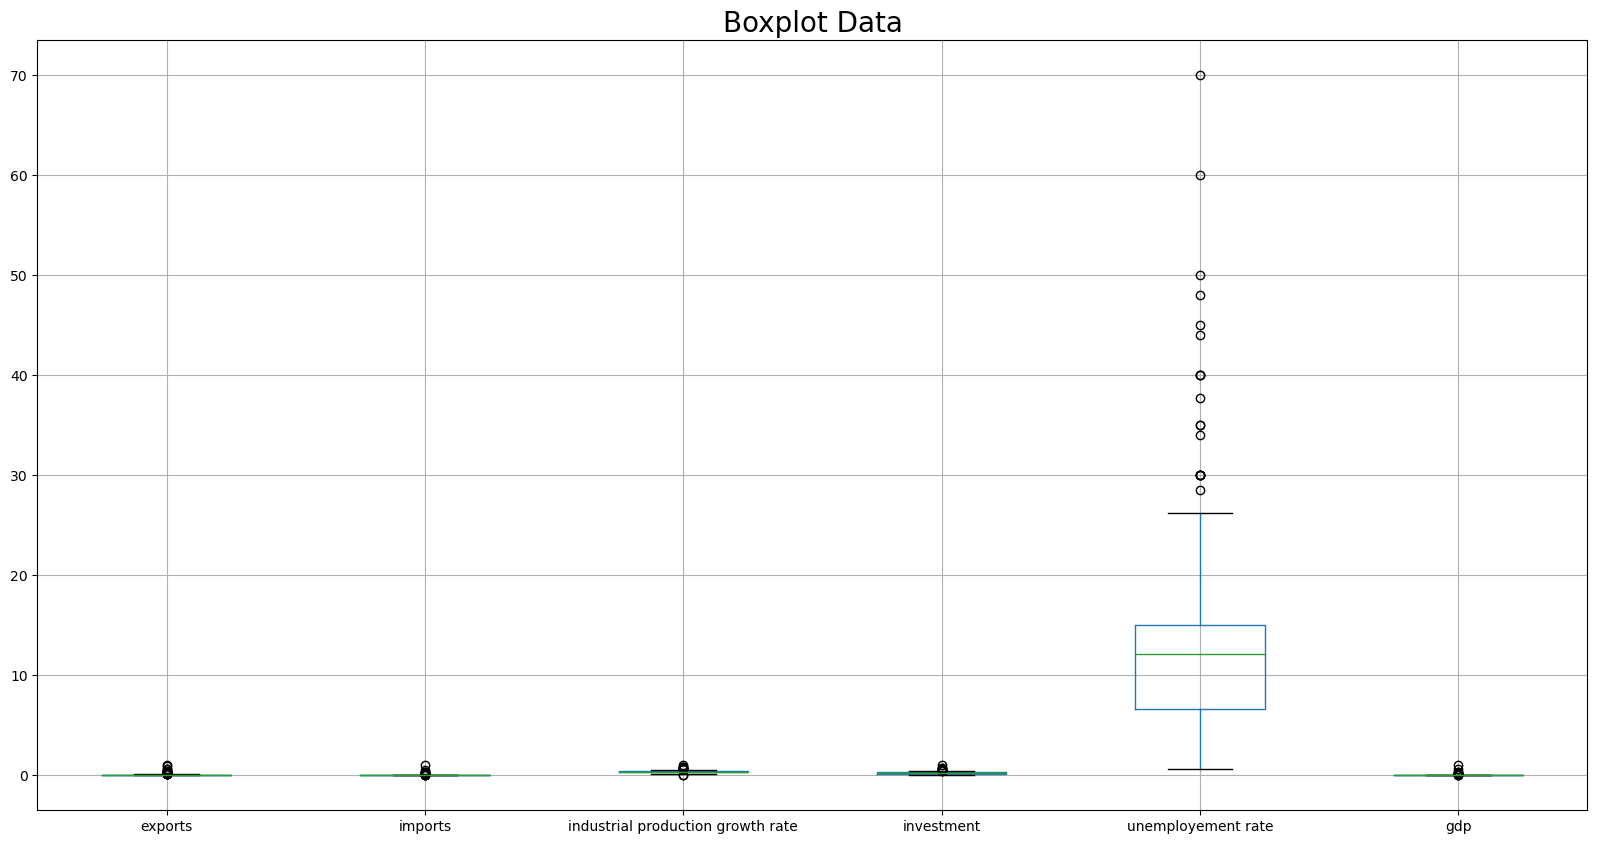

In [34]:
plt.figure(figsize=(20,10))
df.boxplot()
plt.title("Boxplot Data", fontsize=20)
plt.show()

In [35]:
#combine all outliers
outliers = pd.concat([outliers_exports, outliers_imports, outliers_industrial, outliers_investment, outliers_unemployement, outliers_gdp])
outliers = outliers.to_frame(name='value')
outliers

,value
0,0.603154
1,1.000000
6,0.652746
148,0.889958
1,0.485555
6,0.374237
148,1.000000
57,0.788360
58,0.788360
98,0.788360


In [36]:
df = df.drop(outliers.index, axis=0)
df.to_csv('../dataset/clean.csv', index=False)